# **Data Exploration:**


*   Load and display the first few rows of the dataset
*   Summarize the dataset by calculating descriptive statistics (mean, median, standard deviation, etc.).
*   Identify any missing values or anomalies in the dataset.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import datasets, linear_model, model_selection
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report
from sklearn import metrics
import statsmodels.api as sm

In [ ]:
df = pd.read_csv('boston_house_prices.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


# Visualization:
*   Create at least 3 different types of visualizations to explore the relationships between the features and the target variable MEDV. Possible visualizations could include:
  *   Histograms for the distribution of individual features.
  *   Scatter plots showing relationships between features (e.g., RM vs. MEDV, LSTAT vs. MEDV).
  *   Bar plots for categorical data like CHAS.
  *   Correlation heatmaps to show relationships between multiple features, especially their correlation with MEDV.







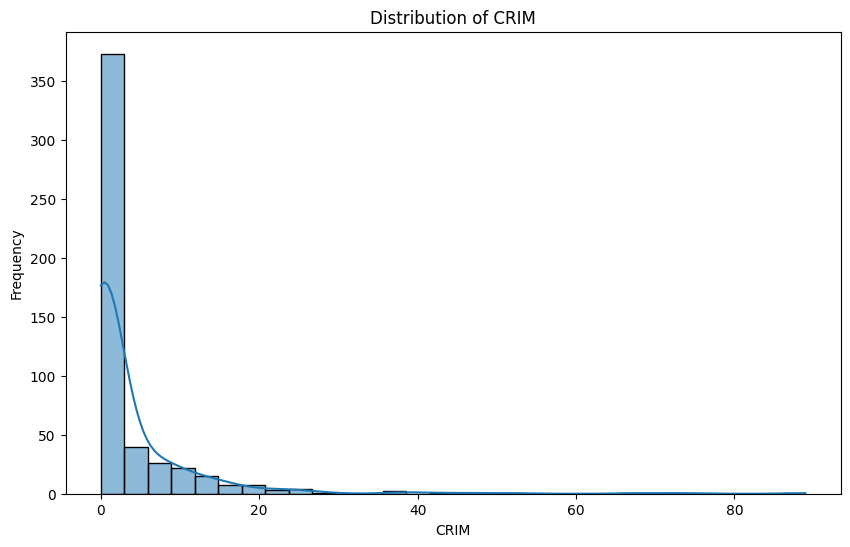

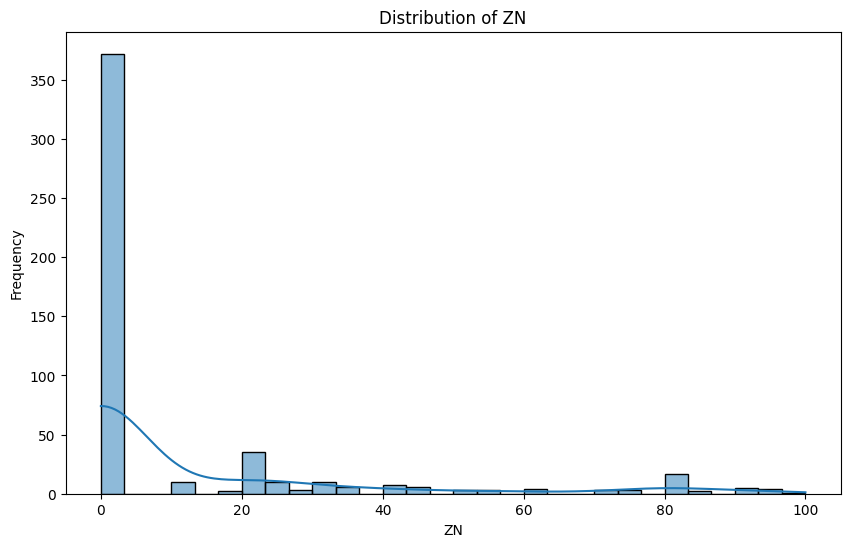

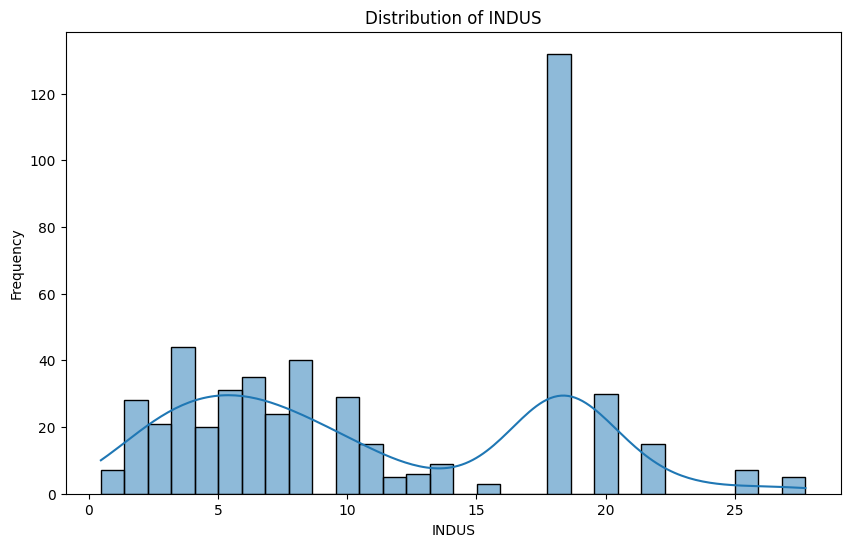

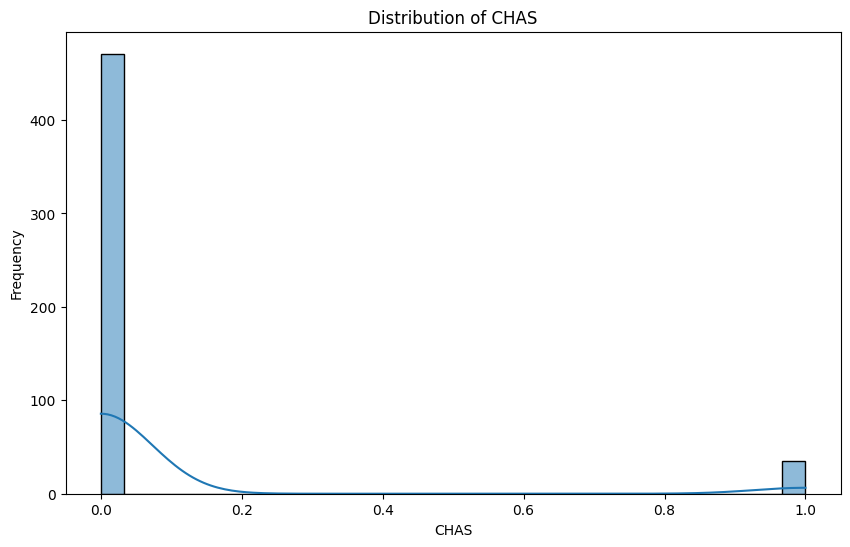

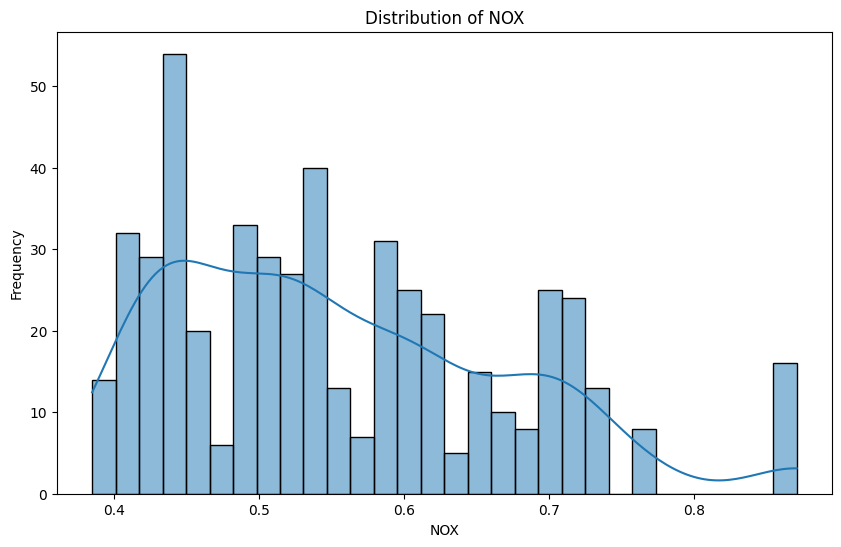

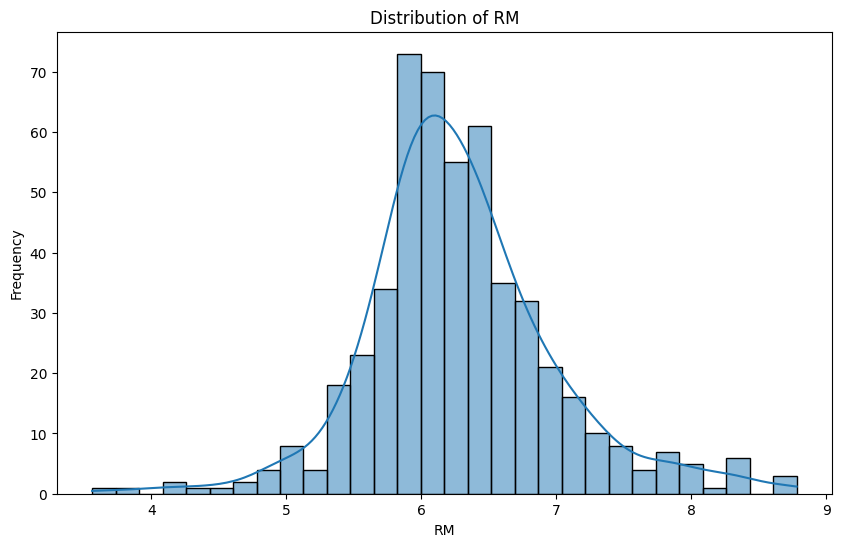

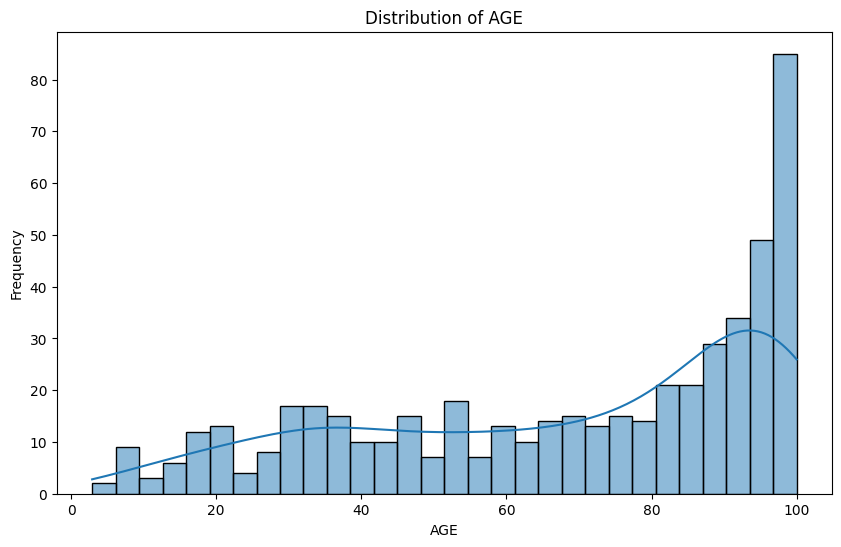

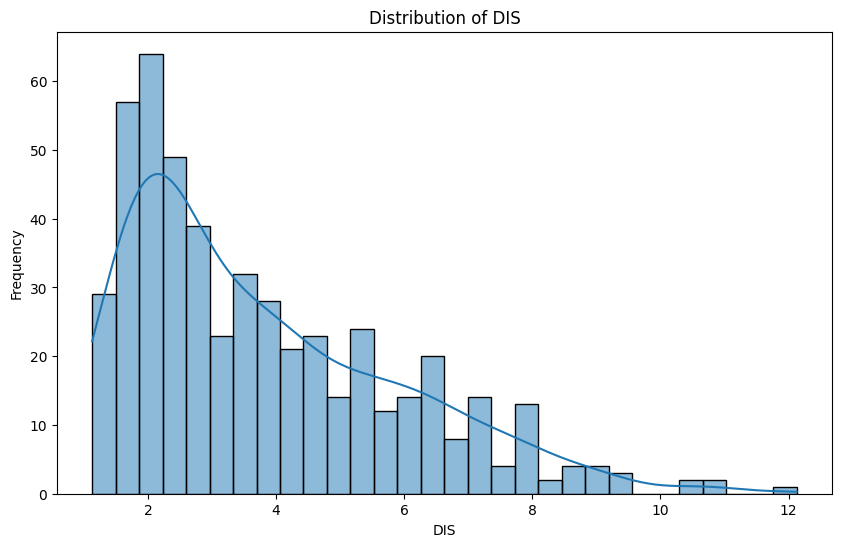

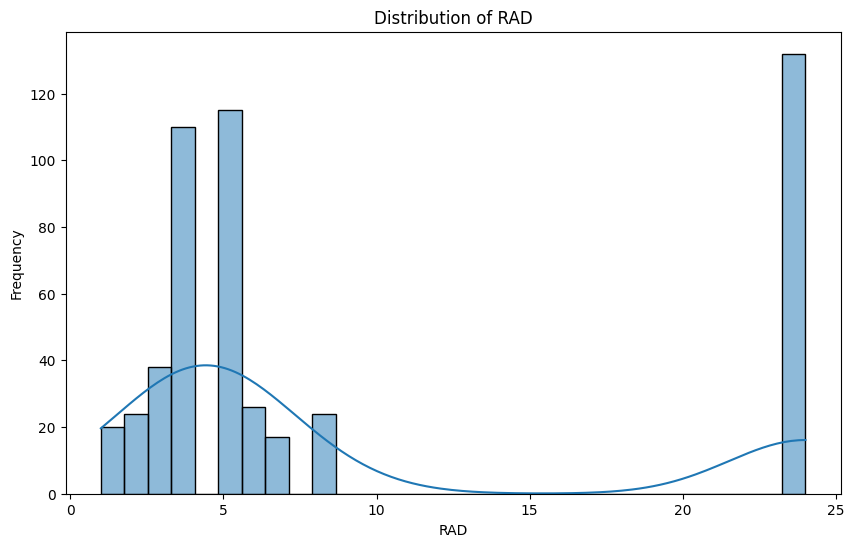

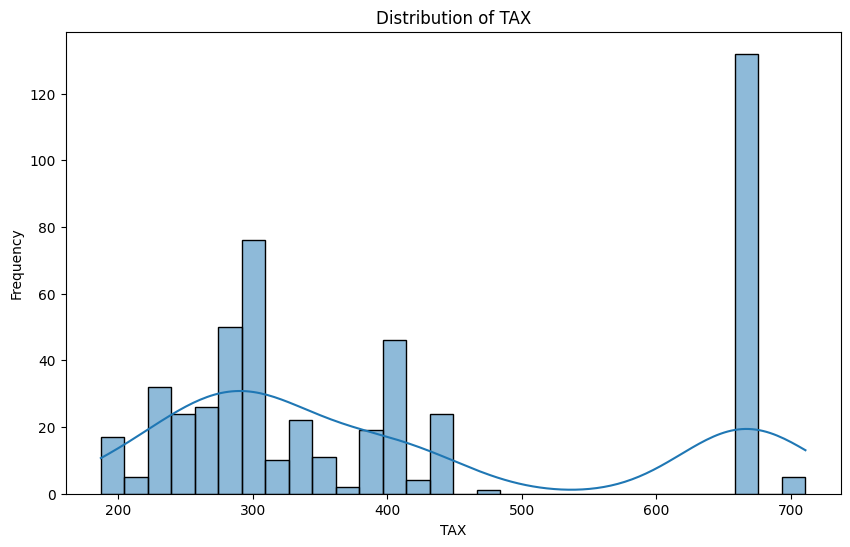

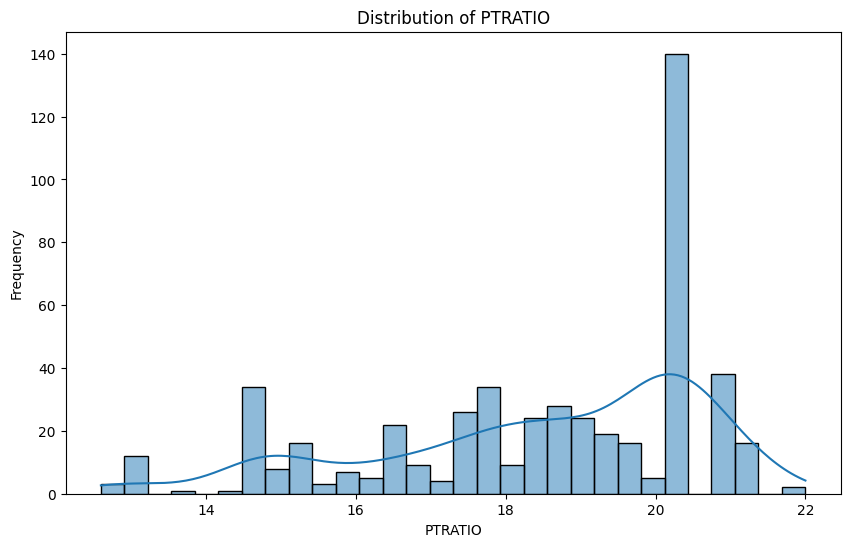

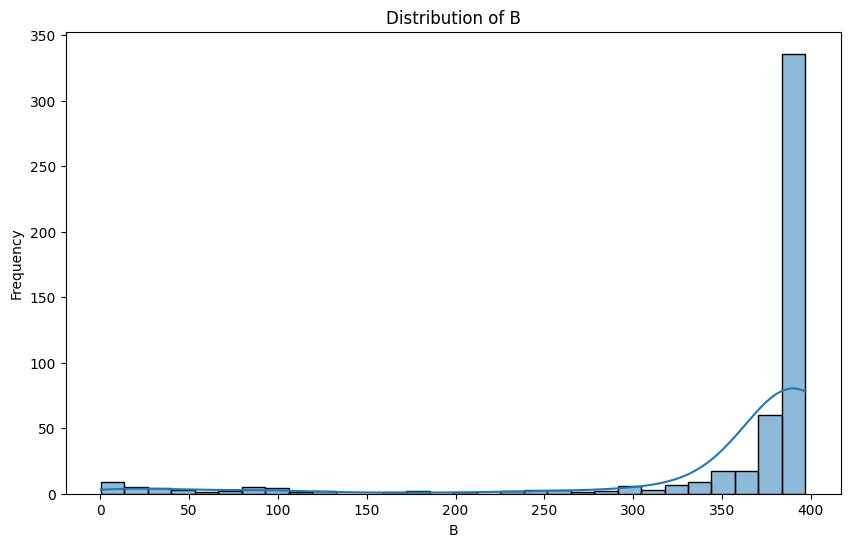

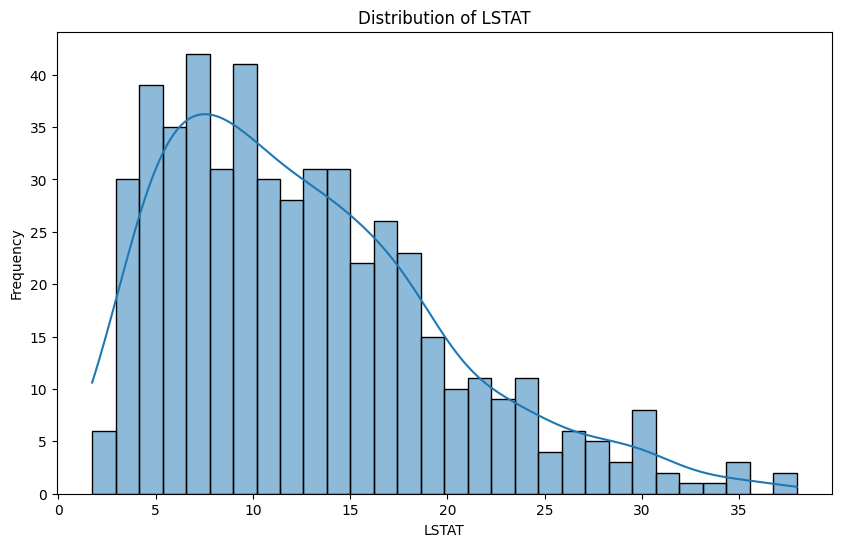

In [ ]:
features = df.columns[:-1]
for feature in features:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

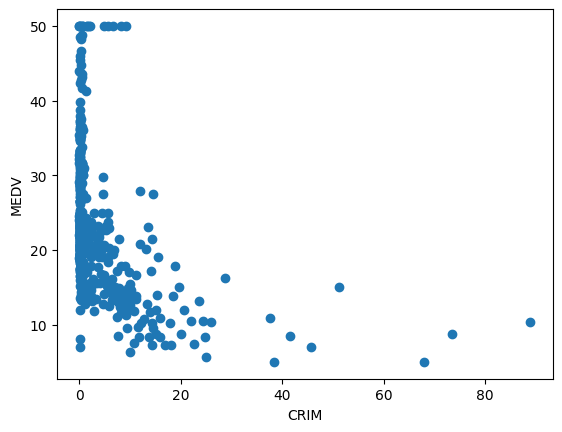

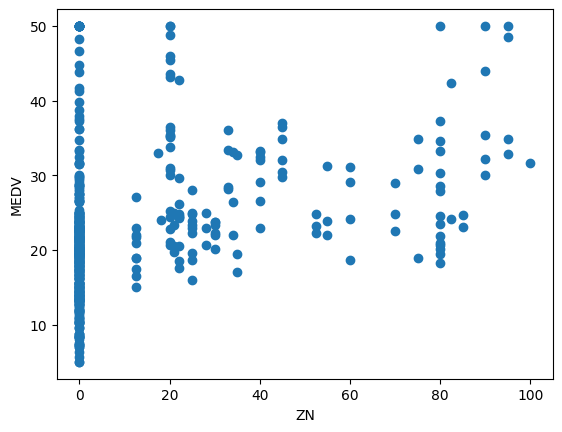

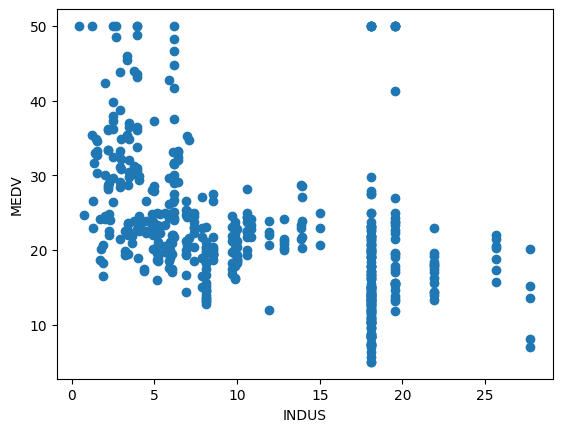

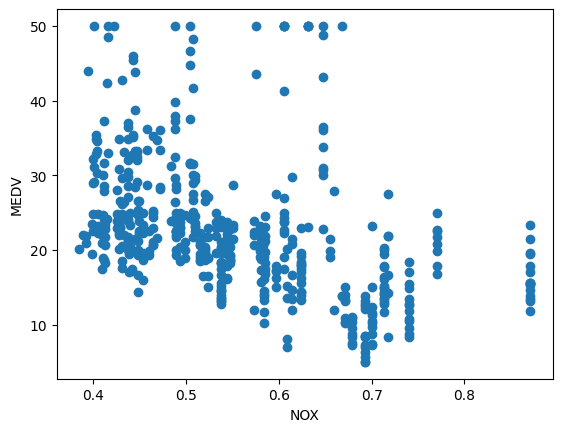

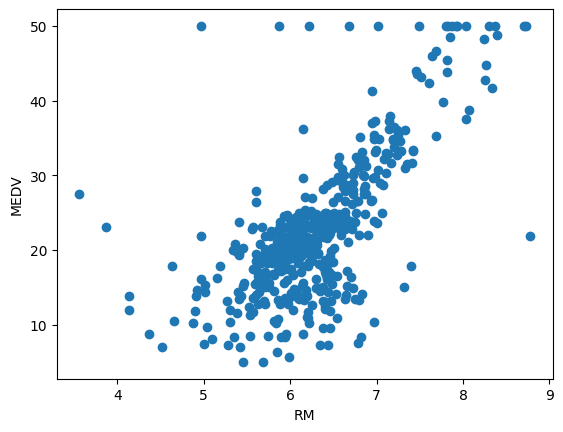

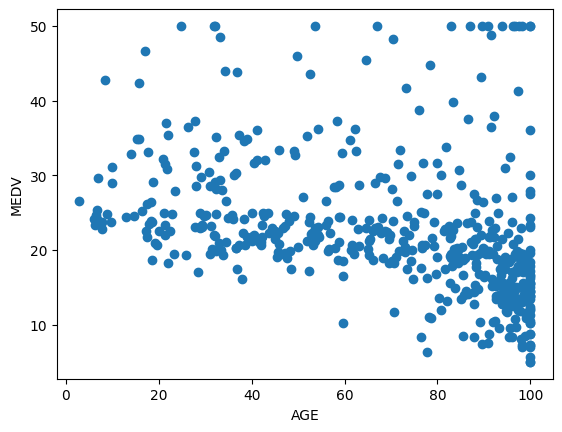

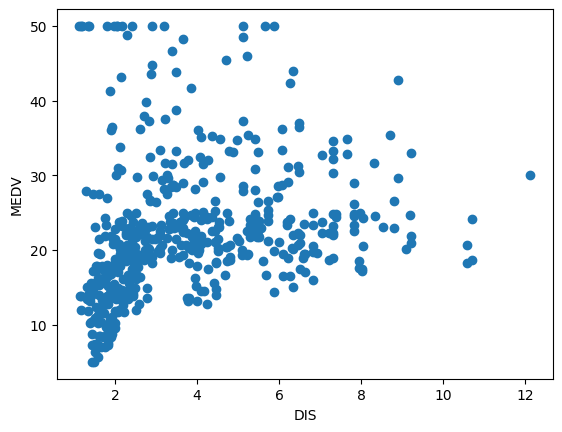

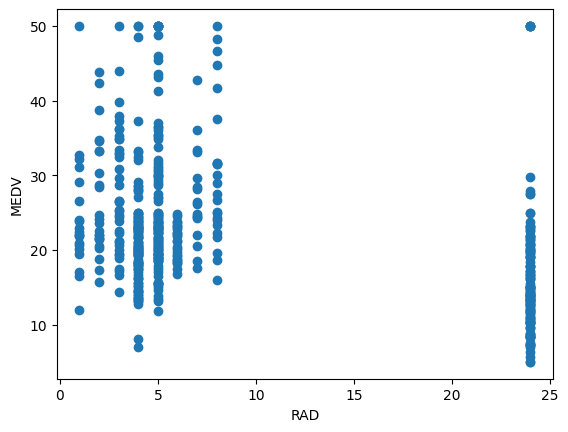

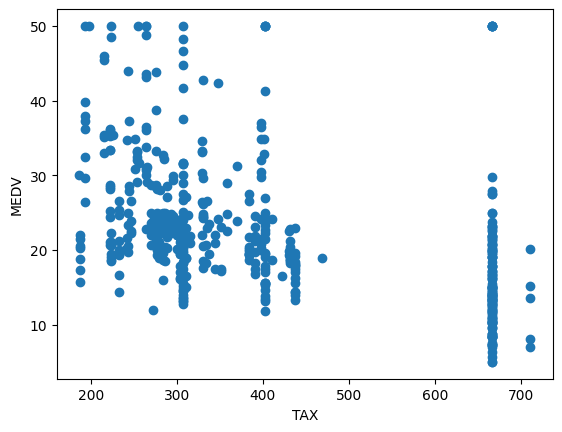

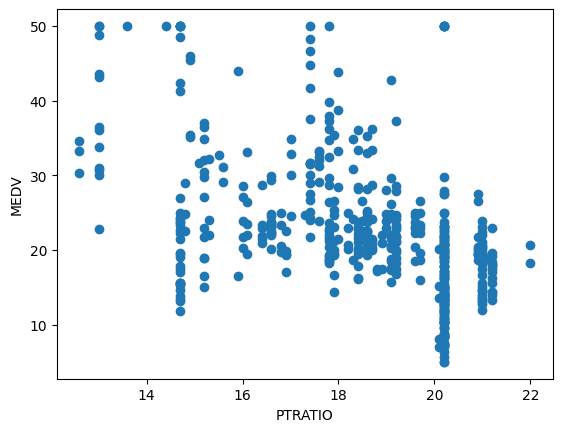

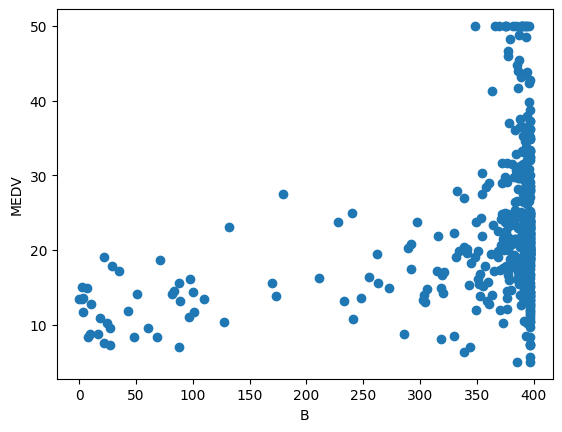

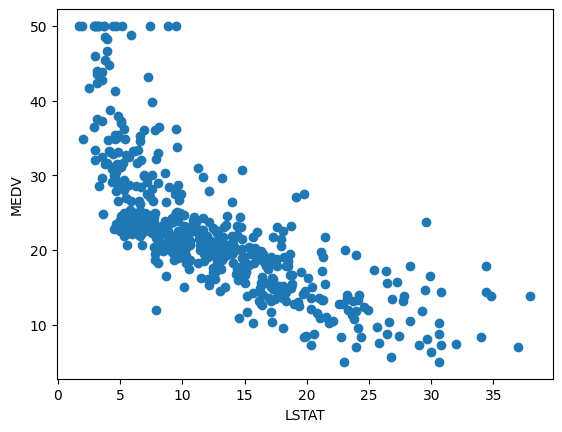

In [ ]:
features = df.columns[:-1]
for f in features:
  if f != 'CHAS':
    plt.scatter(df[f], df['MEDV'])
    plt.xlabel (f)
    plt.ylabel ('MEDV')
    plt.show()

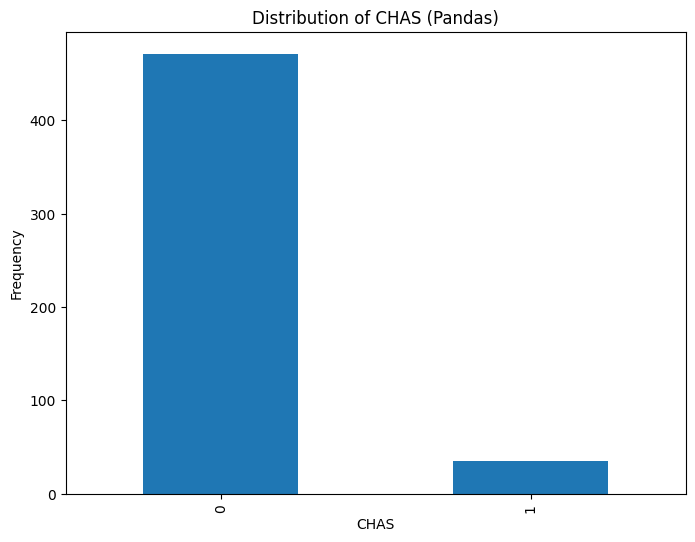

In [ ]:
plt.figure(figsize=(8, 6))
df['CHAS'].value_counts().plot(kind='bar')
plt.title('Distribution of CHAS (Pandas)')
plt.xlabel('CHAS')
plt.ylabel('Frequency')
plt.show()

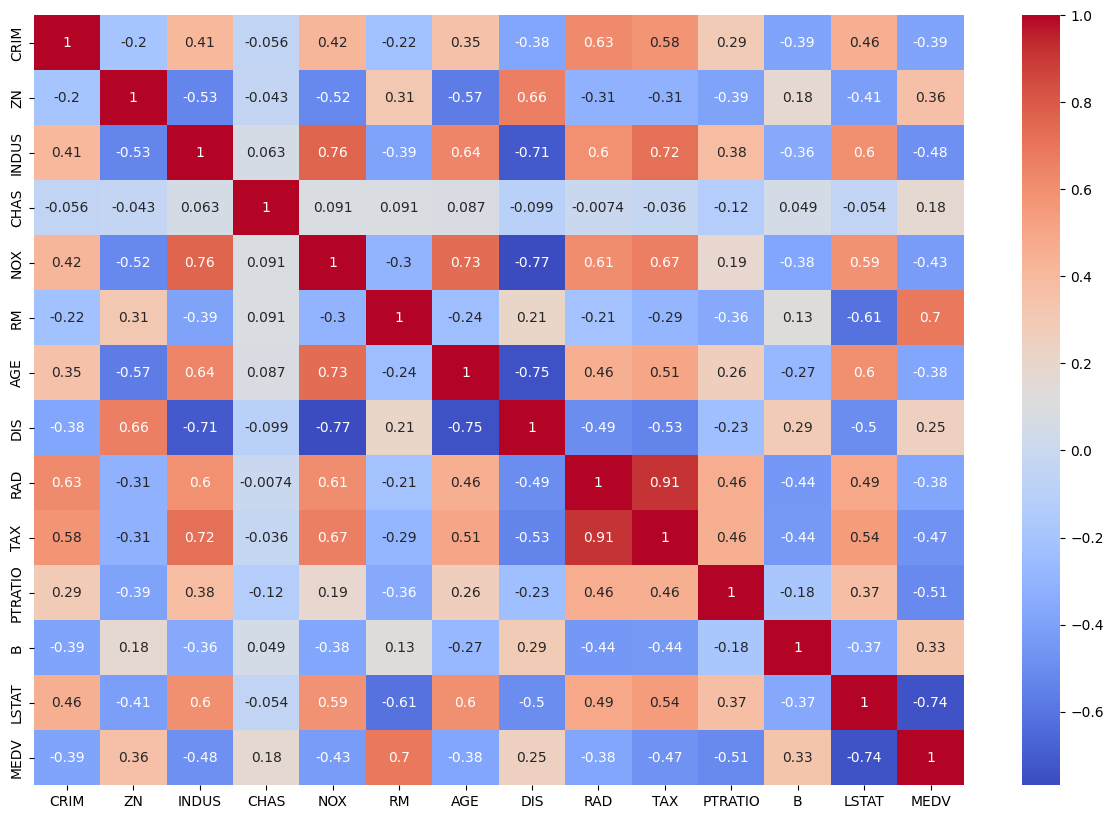

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])  # This ensures 'MEDV' columns are not included

plt.figure(figsize=(15, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
print(df.corr()['MEDV'].sort_values(ascending=False))

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


# Feature Insights:


*   Provide a brief analysis of how each feature might influence the housing price (MEDV).
*   Highlight any correlations or interesting patterns you notice between the features and MEDV.



# Brief Analysis:
*Positive Correlation*


*   RM (0.695360): Strong positive correlation. More rooms in a dwelling significantly increase housing prices, as larger homes are more desirable.

*   ZN (0.360445): Moderate positive correlation. Higher proportions of residential land zoned for larger lots can increase housing prices due to the desirability of spacious residential areas.

*   B (0.333461): Moderate positive correlation. This feature reflects socio-economic factors that can positively influence housing prices.

*   DIS (0.249929): Weak positive correlation. Greater distances to employment centers slightly increase housing prices, possibly due to suburban desirability.

*   CHAS (0.175260): Very weak positive correlation. Proximity to the Charles River can slightly increase housing prices due to scenic views and recreational opportunities.

---

*Negative Correlation*


  * LSTAT (-0.737663): Strong negative correlation. Higher percentages of lower-status populations are strongly associated with lower housing prices due to socio-economic factors.

  * PTRATIO (-0.507787): Moderate negative correlation. Higher pupil-teacher ratios, indicating lower quality of education, are associated with lower housing prices.

  * INDUS (-0.483725): Moderate negative correlation. Higher industrial activity negatively impacts housing prices due to noise and pollution.

  * TAX (-0.468536): Moderate negative correlation. Higher property taxes can decrease housing prices as they increase the cost of homeownership.

  * NOX (-0.427321): Moderate negative correlation. Higher pollution levels are linked to lower housing prices, affecting the quality of life.

  * CRIM (-0.388305): Moderate negative correlation. Higher crime rates generally lead to lower housing prices as safety is a significant concern for homebuyers.

  * RAD (-0.381626): Moderate negative correlation. Better accessibility to highways can slightly decrease housing prices, possibly due to noise and traffic.

  * AGE (-0.376955): Moderate negative correlation. Older homes might have lower prices due to potential maintenance issues, though historical charm can sometimes add value.

---

# Patterns:

  * Two variables that are closely related to the construction of the house itself are RM (0.695360) and ZN (0.360445). A higher number of rooms and a larger land area imply a higher price, as seen by the positive association that both of the aforementioned variables have with house prices. During the house's planning and building phases, both of these variables are likewise under control.
  * There is a negative link between LSTAT (-0.737663), PTRATIO (-0.507787),  and INDUS (-0.483725) home prices. This implies that a high concentration of lower-class residents, a higher student-teacher ratio, and a larger percentage of non-retail business areas may have a negative effect on housing values in a given location. Rather than the house's construction, these three factors are directly tied to its location. This implies that the price of the residence may potentially be impacted by outside variables.
  * Finally, the data is strongly skewed towards 0 (not bound) based on the CHAS bar plot, where the value is either 0 or 1 depending on whether the housing tract is tied to the Charles River. This is because there is a substantial discrepancy in the quantity of data between the two categories.


# Bonus Task: Linear Regression Model:

*   Fit a linear regression model using one or more features to predict MEDV.
*   Evaluate the model's performance (e.g., using R-squared or Mean Squared Error) and interpret the results, including which features are the strongest predictors of housing price.



In [ ]:
lstat = df[['LSTAT']]
rm = df[['RM']]
ptratio = df[['PTRATIO']]
crim = df[['CRIM']]
medv = df[['MEDV']]

In [ ]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(lstat, medv, test_size=0.40)
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

**Linear Regression**

In [ ]:
y_pred = model.predict(X_test)

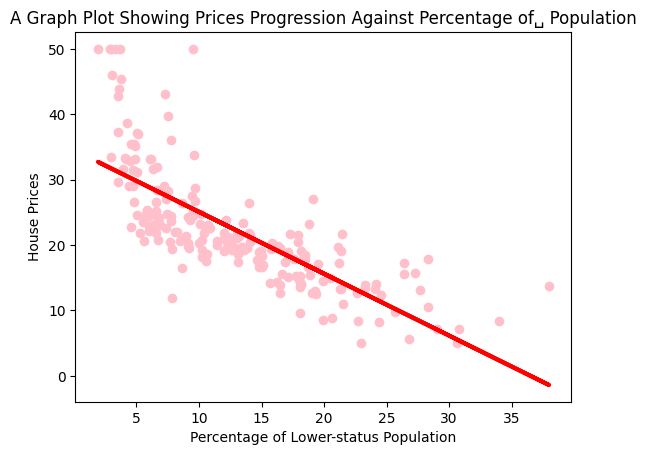

In [ ]:
plt.scatter(X_test, y_test, color='pink')
plt.plot(X_test, y_pred, color='red', linewidth=3)
plt.xlabel('Percentage of Lower-status Population')
plt.ylabel('House Prices')
plt.title('A Graph Plot Showing Prices Progression Against Percentage of␣ Population')
plt.show()

In [ ]:
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))
from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_test, y_pred))

0.5698304404656975
35.429061174357756


In [ ]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(rm, medv, test_size=0.43)
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

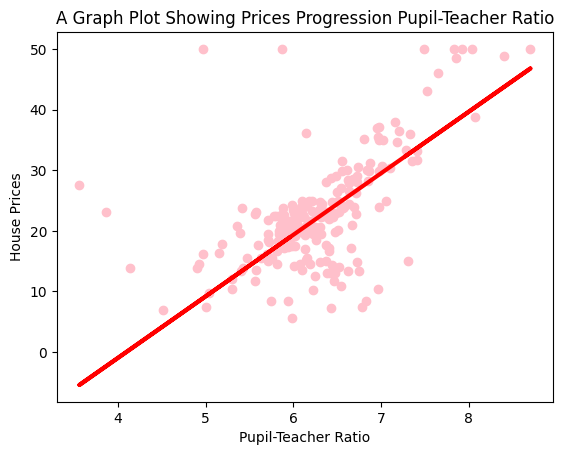

In [ ]:
plt.scatter(X_test, y_test, color='pink')
plt.plot(X_test, y_pred, color='red', linewidth=3)
plt.xlabel('Pupil-Teacher Ratio')
plt.ylabel('House Prices')
plt.title('A Graph Plot Showing Prices Progression Pupil-Teacher Ratio')
plt.show()

In [ ]:
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))
from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_test, y_pred))

0.3077410065836351
54.32232766401709


**Multivalued Linear Regression**

In [ ]:
X = df[['LSTAT', 'RM', 'PTRATIO','CRIM']]
y = df[['MEDV']]

In [ ]:
X = sm.add_constant(X)

In [ ]:
model = sm.OLS(y, X).fit()

In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     268.0
Date:                Mon, 16 Sep 2024   Prob (F-statistic):          5.84e-123
Time:                        15:18:52   Log-Likelihood:                -1550.8
No. Observations:                 506   AIC:                             3112.
Df Residuals:                     501   BIC:                             3133.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.9233      3.976      4.257      0.0